In [2]:
# Run this cell to install required libraries and import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn makes matplotlib plots look prettier!

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 1: Load the Data
Use `pandas` to read the CSV file from the provided URL.

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# TODO: use pd.read_csv() to load the data into a dataframe named 'df'
df = pd.read_csv(url)

# --- SANITY CHECK ---
assert 'df' in locals(), "Error: You didn't name your dataframe 'df'."
assert len(df) == 891, f"Error: Expected 891 rows, but got {len(df)}. Check your loading code."
print("✅ Data loaded perfectly! Move to the next step.")
df.head()



✅ Data loaded perfectly! Move to the next step.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 2: Clean the Data
Real-world data is messy. Let's find out what is missing and fix it.

In [4]:
# TODO: Print out the sum of null values for every column
# Hint: use df.isnull().sum()
print(df.isnull().sum())

# TODO: The 'Age' column has missing values. Fill the missing ages with the median age of the passengers.
# Hint: df['Age'].fillna(...)
df['Age'] = df['Age'].fillna(df['Age'].median)

print("Missing values handled!")

# --- SANITY CHECK ---
assert df['Age'].isnull().sum() == 0, "Error: There are still missing values in the Age column!"
print("✅ Missing ages handled perfectly!")

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing values handled!
✅ Missing ages handled perfectly!


### Step 3: Visualize
Time to draw some graphs. Create at least 3 plots below.
Ideas: Survival rate by Gender, Passenger Class vs Survival, or an Age distribution histogram.

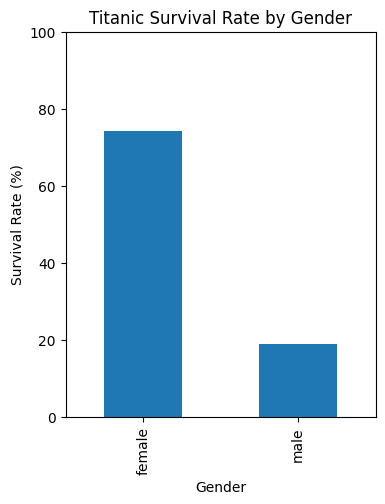

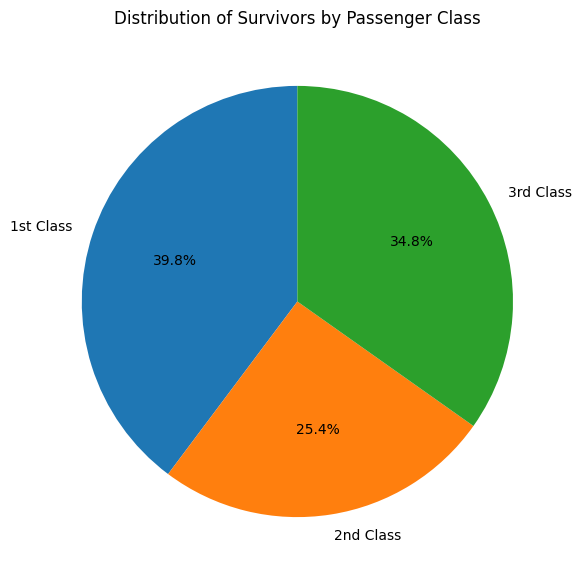

/tmp/ipykernel_25214/231642939.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100


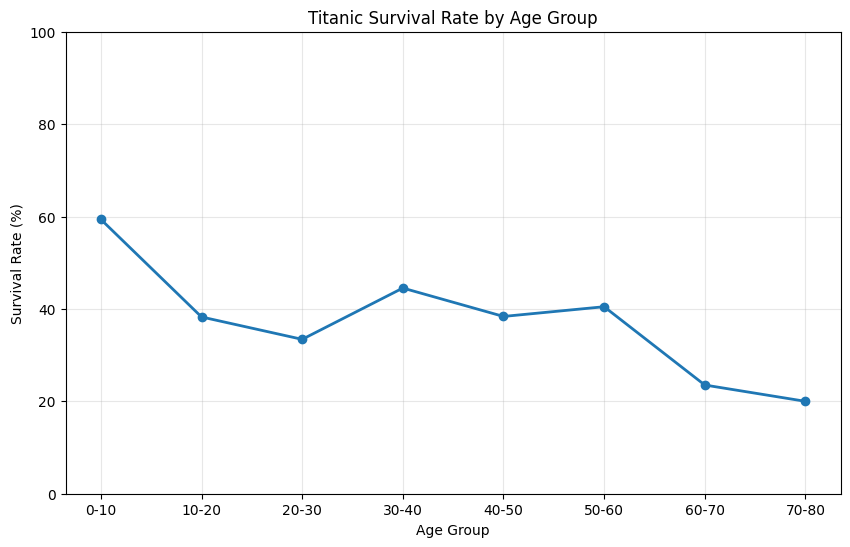

In [31]:
# TODO: Plot 1
# YOUR CODE HERE
survival_by_gender = df.groupby('Sex')['Survived'].mean() * 100

plt.figure(figsize=(4,5))
survival_by_gender.plot(kind='bar')

plt.title('Titanic Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
plt.ylim(0,100)
plt.show()

# TODO: Plot 2
# YOUR CODE HERE
survivors_by_class = df[df['Survived'] == 1].groupby('Pclass').size()
plt.figure(figsize=(7,7))
plt.pie(
    survivors_by_class,
    labels=['1st Class', '2nd Class', '3rd Class'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Survivors by Passenger Class')
plt.show()

# TODO: Plot 3
# YOUR CODE HERE
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
labels = ['0-10', '10-20', '20-30', '30-40',
          '40-50', '50-60', '60-70', '70-80']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100
plt.figure(figsize=(10,6))

plt.plot(
    survival_by_age.index,
    survival_by_age.values,
    marker='o',
    linewidth=2
)

plt.title('Titanic Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.ylim(0,100)
plt.grid(True, alpha=0.3)

plt.show()